<a href="https://colab.research.google.com/github/nana0917/Lab-PDI/blob/main/Practica_6_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Práctica 6**- Operaciones aritméticas y lógicas

Lab. Procesamiento Digital de Imagenes

**Ejercicio 1:** Suma de imágenes

1. Cargar dos imágenes médicas en escala de grises del mismo tamaño, en caso contrario, ajustar a la misma resolución.

2. Aplicar la suma ponderada con diferentes pesos.

3. Aplicar la suma promedio de las dos imágenes.

4. Mostrar resultados con imágenes originales.


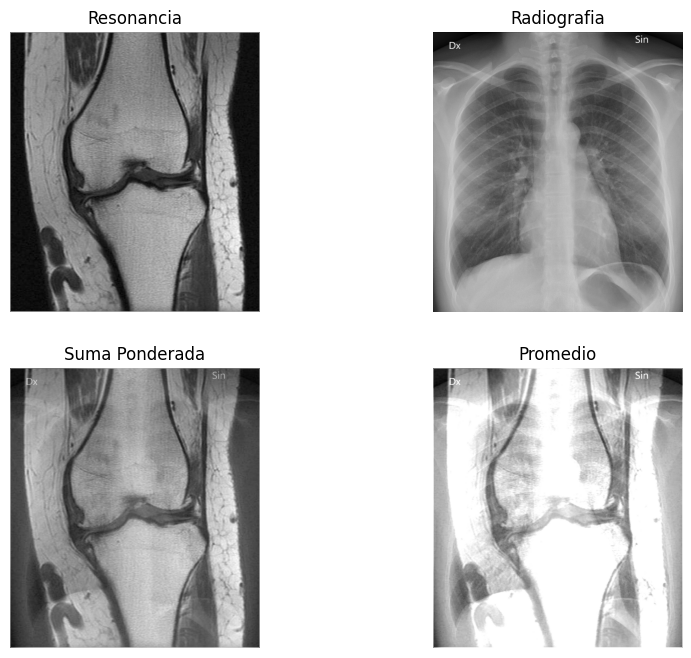

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imágenes
img1 = cv2.imread('img resonancia.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img radiografia.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error al cargar imágenes")
else:
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    suma_ponderada = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)
    promedio = cv2.add(img1, img2) // 2

    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(img1, cmap='gray')
    plt.title('Resonancia')
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(img2, cmap='gray')
    plt.title('Radiografia')
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.imshow(suma_ponderada, cmap='gray')
    plt.title('Suma Ponderada')
    plt.axis('off')

    plt.subplot(2,2,4)
    plt.imshow(promedio, cmap='gray')
    plt.title('Promedio')
    plt.axis('off')

    plt.show()

En este ejercicio se realiza la suma de dos imágenes médicas en escala de grises.
Se aplica una suma ponderada para combinar ambas imágenes con diferentes pesos,
así como un promedio para obtener una mezcla equilibrada.

**Ejercicio 2:** Resta de imágenes.

1. Restar las dos imágenes y analizar el resultado.

2. Usar la función “cv2.absdiff” para evitar valores negativos.

3. Mostrar resultados.

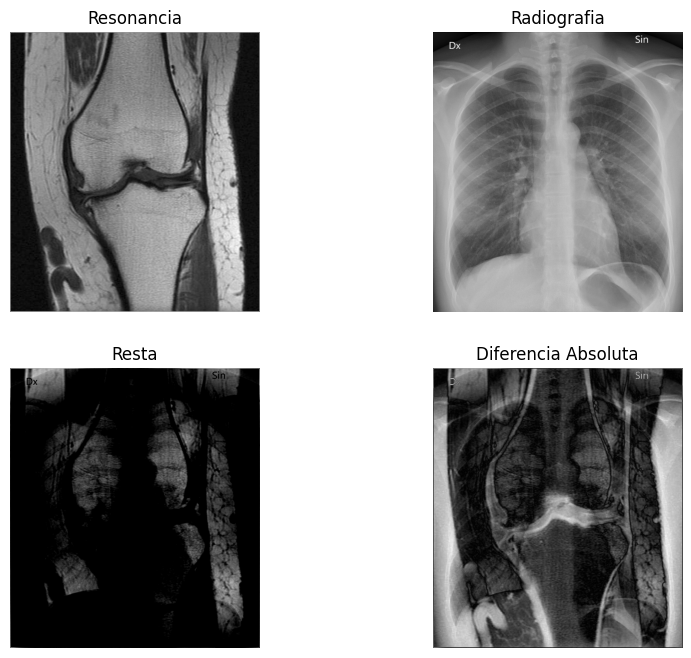

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imágenes
img1 = cv2.imread('img resonancia.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img radiografia.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error al cargar imágenes")
else:
    # Ajustar tamaño si es necesario
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # 🔹 Resta directa
    resta = cv2.subtract(img1, img2)

    # 🔹 Diferencia absoluta (recomendada)
    abs_diff = cv2.absdiff(img1, img2)

    # Mostrar resultados
    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(img1, cmap='gray')
    plt.title('Resonancia')
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(img2, cmap='gray')
    plt.title('Radiografia')
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.imshow(resta, cmap='gray')
    plt.title('Resta')
    plt.axis('off')

    plt.subplot(2,2,4)
    plt.imshow(abs_diff, cmap='gray')
    plt.title('Diferencia Absoluta')
    plt.axis('off')

    plt.show()

En este ejercicio se realiza la resta entre dos imágenes para identificar diferencias.
También se utiliza la función de diferencia absoluta para evitar valores negativos
y mejorar la visualización de los cambios.

**Ejercicio 3:** Multiplicación por un factor.

1. Aplicar un factor de multiplicación a cada imagen médica para modificar su brillo.

2. Comparar los efectos con 3 diferentes factores para cada imagen.

3. Mostrar resultados.

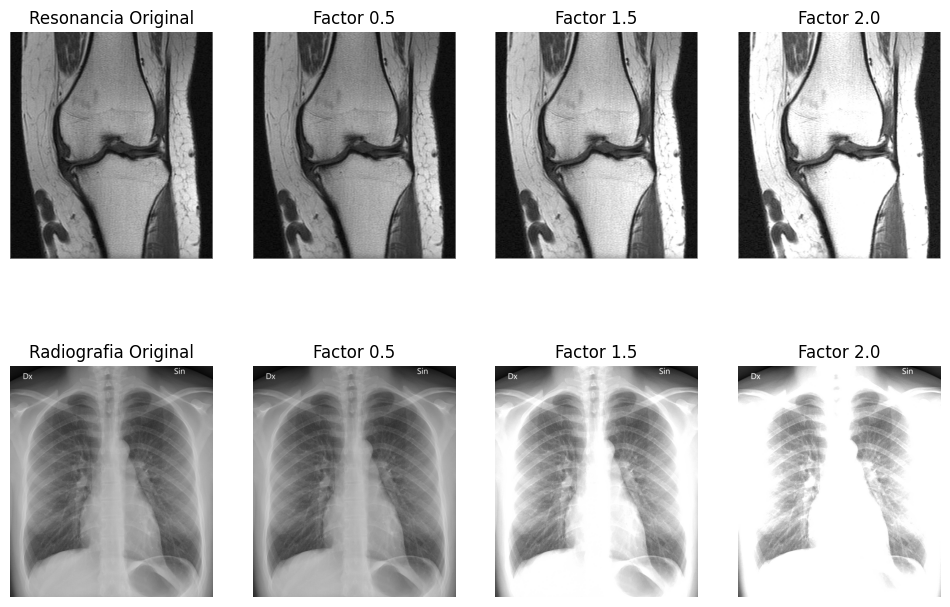

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imágenes
img1 = cv2.imread('img resonancia.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img radiografia.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error al cargar imágenes")
else:
    # Convertir a float para evitar saturación
    img1_float = img1.astype(np.float32)
    img2_float = img2.astype(np.float32)

    # Factores
    factores = [0.5, 1.5, 2.0]

    # Aplicar factores a imagen 1
    resultados_img1 = [np.clip(img1_float * f, 0, 255) for f in factores]

    # Aplicar factores a imagen 2
    resultados_img2 = [np.clip(img2_float * f, 0, 255) for f in factores]

    # Mostrar resultados
    plt.figure(figsize=(12,8))

    # Imagen 1
    plt.subplot(2,4,1)
    plt.imshow(img1, cmap='gray')
    plt.title('Resonancia Original')
    plt.axis('off')

    for i, res in enumerate(resultados_img1):
        plt.subplot(2,4,i+2)
        plt.imshow(res, cmap='gray')
        plt.title(f'Factor {factores[i]}')
        plt.axis('off')

    # Imagen 2
    plt.subplot(2,4,5)
    plt.imshow(img2, cmap='gray')
    plt.title('Radiografia Original')
    plt.axis('off')

    for i, res in enumerate(resultados_img2):
        plt.subplot(2,4,i+6)
        plt.imshow(res, cmap='gray')
        plt.title(f'Factor {factores[i]}')
        plt.axis('off')

    plt.show()

En este ejercicio se modifica el brillo de una imagen mediante la multiplicación
por un factor constante. Se analizan los efectos de diferentes valores sobre la intensidad.

**Ejercicio 4: **Multiplicación elemento por elemento.

1. Multiplicar las dos imágenes médicas píxel a píxel.

2. Analizar en qué aplicaciones biomédicas podría ser útil esta operación.

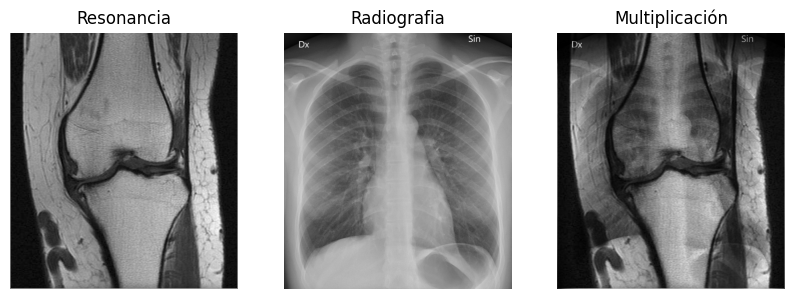

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imágenes
img1 = cv2.imread('img resonancia.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img radiografia.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error al cargar imágenes")
else:
    # Ajustar tamaño si es necesario
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Convertir a float para evitar saturación
    img1_float = img1.astype(np.float32)
    img2_float = img2.astype(np.float32)

    # Multiplicación elemento por elemento
    multiplicacion = img1_float * img2_float

    # Normalizar para visualizar
    multiplicacion = np.clip(multiplicacion / 255, 0, 255)

    # Mostrar resultados
    plt.figure(figsize=(10,8))

    plt.subplot(1,3,1)
    plt.imshow(img1, cmap='gray')
    plt.title('Resonancia')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img2, cmap='gray')
    plt.title('Radiografia')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(multiplicacion, cmap='gray')
    plt.title('Multiplicación')
    plt.axis('off')

    plt.show()

En este ejercicio se realiza la multiplicación píxel a píxel entre dos imágenes.
Esta operación permite resaltar coincidencias entre ambas imágenes.

**Parte II.-** Operaciones lógicas

**Ejercicio 1** Ecualización.

1. Cargar una imagen médica con bajo contraste.

2. Obtener y visualizar el histograma de la imagen original.

3. Aplicar ecualización de histograma para mejorar el contraste.

4. Mostrar la imagen original, la imagen mejorada y comparar los histogramas.

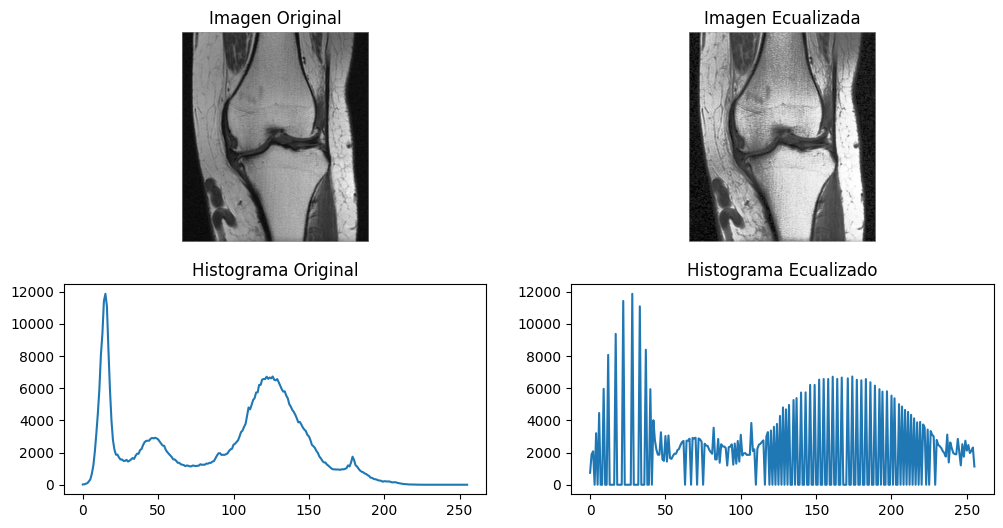

In [17]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen médica (gris)
img = cv2.imread('img resonancia.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error al cargar la imagen")
else:
    # Histograma original
    hist_gray = cv2.calcHist([img], [0], None, [256], [0, 256])

    # Ecualización
    equalized = cv2.equalizeHist(img)

    # Histograma ecualizado
    hist_eq = cv2.calcHist([equalized], [0], None, [256], [0, 256])

    # Mostrar resultados
    plt.figure(figsize=(12,6))

    # Imagen original
    plt.subplot(2,2,1)
    plt.imshow(img, cmap='gray')
    plt.title('Imagen Original')
    plt.axis('off')

    # Imagen ecualizada
    plt.subplot(2,2,2)
    plt.imshow(equalized, cmap='gray')
    plt.title('Imagen Ecualizada')
    plt.axis('off')

    # Histograma original
    plt.subplot(2,2,3)
    plt.plot(hist_gray)
    plt.title('Histograma Original')

    # Histograma ecualizado
    plt.subplot(2,2,4)
    plt.plot(hist_eq)
    plt.title('Histograma Ecualizado')

    plt.show()



En este ejercicio se aplica la ecualización de histograma a una imagen médica
para mejorar su contraste. Se comparan los histogramas antes y después del proceso.